# Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM, MultiCamSampling
from multicam.qt import qt, qt_gauss
from scipy.stats import spearmanr


from multicam_tng.utils import get_an_from_mpeak_mah, generate_randoms
from astropy.table import Table
from scipy.stats import spearmanr


TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit
RESOLUTION_CUT = np.log10(1.4e6 * 100 * TNG_H)  # see TNG data access website


from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


In [3]:
# this is just metadata which sims share
metadata = pd.read_csv("../../data/tng300-1-table.csv")
redshift_snaps = metadata["Redshift"].values
scales = 1 / (1 + redshift_snaps)
scales.shape

(100,)

In [4]:
# load data
_hydro_raw = Table.read("../../data/hydro_final.ecsv")
flag = _hydro_raw["SubhaloFlag"]
hydro_raw = _hydro_raw[flag == 1]
len(hydro_raw)

101364

In [5]:
# Add z12
hydro_raw["z12"] = (1 / hydro_raw["a12"]) - 1

In [6]:
# apply lower cut on mpeak (resolution) only and use this catalog for SHAM application
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_mask = log_mpeak > 11
hydro_high = hydro_raw[mpeak_cut_mask]
len(hydro_high)

12652

In [8]:
# sham application
x = np.log10(hydro_high["mpeak"].data)
y = np.log10(hydro_high["stellar_mass"].data)
logmstar_sham_high = qt(x, y)
logmstar_sham_high.shape

(12652,)

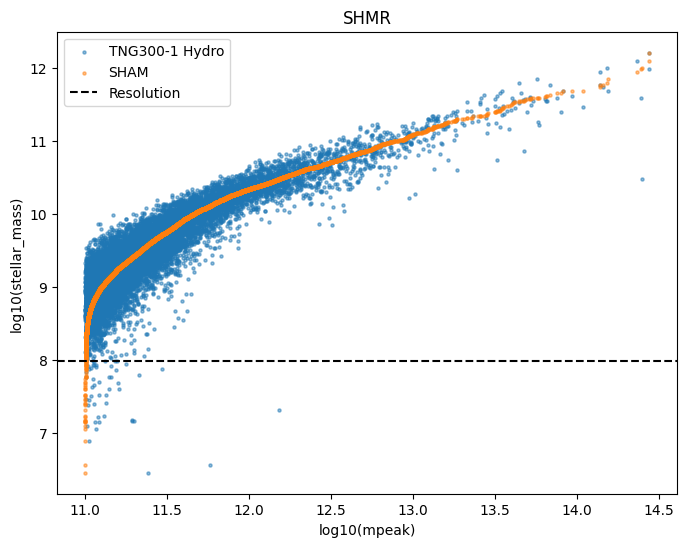

In [9]:
# SHMR
plt.figure(figsize=(8, 6))
plt.scatter(
    np.log10(hydro_high["mpeak"].data),
    np.log10(hydro_high["stellar_mass"].data),
    s=5,
    alpha=0.5,
    label="TNG300-1 Hydro",
)
plt.scatter(
    np.log10(hydro_high["mpeak"].data),
    logmstar_sham_high,
    s=5,
    alpha=0.5,
    label="SHAM",
)
plt.xlabel("log10(mpeak)")
plt.ylabel("log10(stellar_mass)")
plt.title("SHMR")
plt.axhline(RESOLUTION_CUT, c="k", ls="--", label="Resolution")

plt.legend()

# objects below resolution cut that make into SHMR (not sample, lower mpeak cut not applied)
# TODO: actually need to look
# print(f"Objects below resolution cut: {}")

In [11]:
x1 = np.log10(hydro_raw["stellar_mass"])
x2 = np.log10(hydro_raw["mpeak"])  # resolution

# NOTE: no cut on x2 high, only cut on x2 for low resolution
star_mask = (x1 > 9.5) & (x1 < 10.2) & (x2 > 11)
hydro_mstar_cut = hydro_raw[star_mask]
len(hydro_mstar_cut)

4050

In [12]:
# get sham stellar mass bin predicted catalog
sham_mask = (logmstar_sham_high > 9.5) & (logmstar_sham_high < 10.2)
hydro_sham = hydro_high[sham_mask]
len(hydro_sham)


4050

In [16]:
# how many objects in multicam training do not pass resolution cut?
_x = np.log10(hydro_raw["mpeak"])
mask = (_x > 11) & (_x < 12)
hydro_mpeak = hydro_raw[mask]

_n_bad = sum(np.log10(hydro_mpeak["stellar_mass"]) <= RESOLUTION_CUT)
print(
    f"n_bad: {int(_n_bad)}, fraction (of training set): {_n_bad / len(hydro_mpeak) * 100:.3f} %"
)

n_bad: 45, fraction (of training set): 0.398 %


## Distributions in different bins

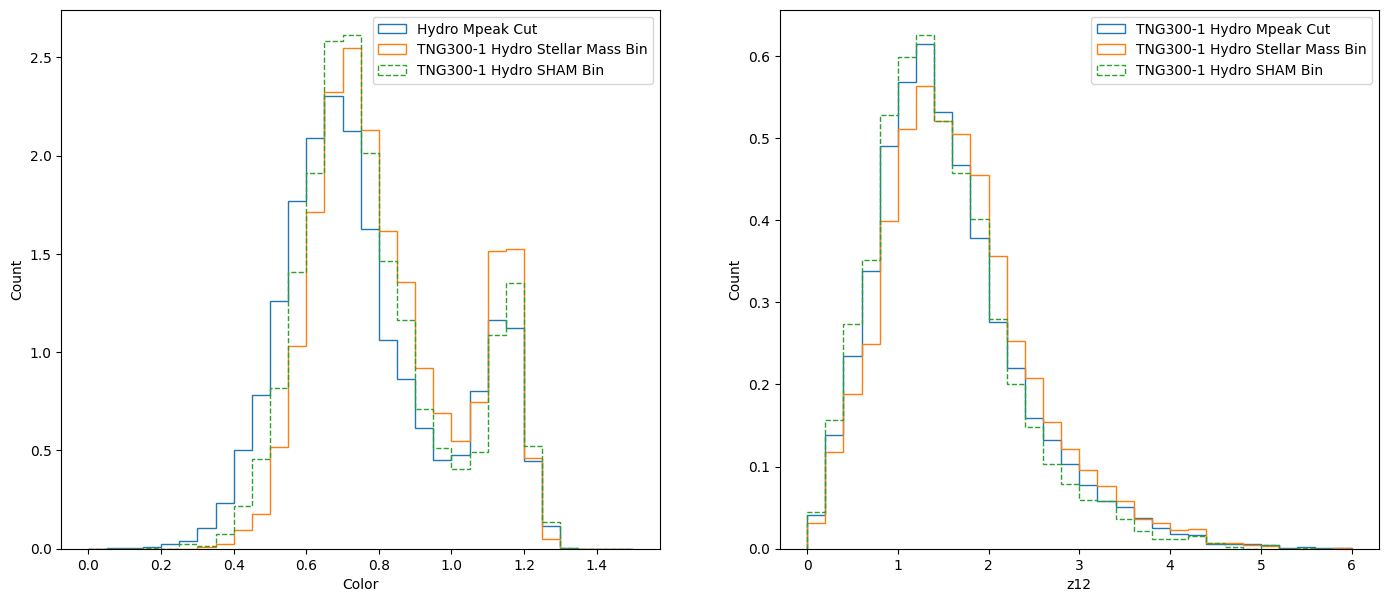

In [11]:
# let's look at color and z12 distributions in stellar mass bin and sham mass bin
# compared with distribution on mpeak cut only (i.e. hydro_high)

# stellar mass bin
plt.figure(figsize=(17, 7))
plt.subplot(1, 2, 1)
bins = np.linspace(0, 1.5, 31)

log_mpeak = np.log10(hydro_raw["mpeak"])
__mpeak_cut_mask = (log_mpeak > 11) & (log_mpeak < 12)
hydro_mpeak_cut = hydro_raw[__mpeak_cut_mask]

plt.hist(
    hydro_mpeak_cut["color"].data,
    bins=bins,
    histtype="step",
    density=True,
    label="Hydro Mpeak Cut",
)

plt.hist(
    hydro_mstar_cut["color"].data,
    bins=bins,
    histtype="step",
    density=True,
    label="TNG300-1 Hydro Stellar Mass Bin",
)

plt.hist(
    hydro_sham["color"].data,
    bins=bins,
    histtype="step",
    density=True,
    ls="--",
    label="TNG300-1 Hydro SHAM Bin",
)


plt.xlabel("Color")
plt.ylabel("Count")
plt.legend(loc="best")

bins = np.linspace(0, 6, 31)
plt.subplot(1, 2, 2)

plt.hist(
    hydro_mpeak_cut["z12"].data,
    bins=bins,
    histtype="step",
    density=True,
    label="TNG300-1 Hydro Mpeak Cut",
)

plt.hist(
    hydro_mstar_cut["z12"].data,
    bins=bins,
    histtype="step",
    density=True,
    label="TNG300-1 Hydro Stellar Mass Bin",
)


plt.hist(
    hydro_sham["z12"].data,
    bins=bins,
    histtype="step",
    density=True,
    ls="--",
    label="TNG300-1 Hydro SHAM Bin",
)

plt.xlabel("z12")
plt.ylabel("Count")
plt.legend(loc="best")

# they are all different!
# so we cannot simple reproduce mpeak cut one with MultiCAM need to match to one of the others.

# CAM Prediction in SHAM bin

In [17]:
# CAM prediction for color
color_cam_pred = qt(hydro_sham["z12"].data, hydro_mstar_cut["color"])
color_cam_pred.shape

(4050,)

In [18]:
ns = np.linspace(0, 1, 11)[1:-1]
ns

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [19]:
# NOTE: can only train multicam on mpeak mass bin
x_train = get_an_from_mpeak_mah(hydro_mpeak["mpeak_mah"], scales=scales, ns=ns)
y_train = hydro_mpeak["color"].reshape(-1, 1)

# but we want to apply on SHAM bin
x_test = get_an_from_mpeak_mah(hydro_sham["mpeak_mah"], scales=scales, ns=ns)

# and reproduce the color distribution in the true stellar mass bin!
y_true = hydro_mstar_cut["color"].reshape(-1, 1)

x_train.shape, y_train.shape, x_test.shape, y_true.shape


((11310, 9), (11310, 1), (4050, 9), (4050, 1))

In [20]:
model = MultiCAM(9, 1)
model.fit(x_train, y_train)
color_multicam_pred = model.predict(x_test, y_target=y_true)[..., 0]
color_multicam_pred.shape

(4050,)

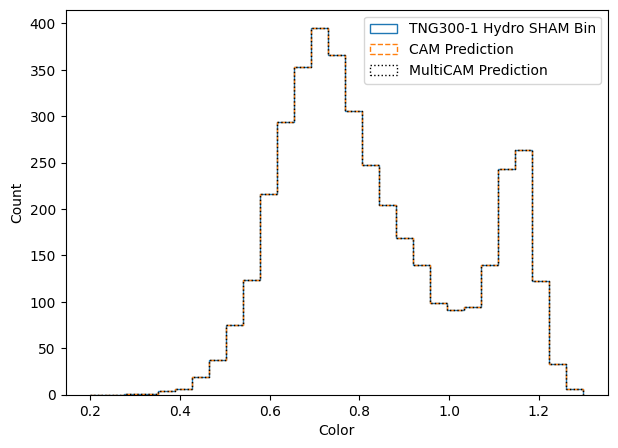

In [21]:
# histogram of color distribution
plt.figure(figsize=(7, 5))
bins = np.linspace(0.2, 1.3, 30)
plt.hist(
    hydro_mstar_cut["color"].data,
    bins=bins,
    histtype="step",
    label="TNG300-1 Hydro SHAM Bin",
)
plt.hist(color_cam_pred, bins=bins, histtype="step", ls="--", label="CAM Prediction")
plt.hist(
    color_multicam_pred,
    bins=bins,
    histtype="step",
    ls=":",
    label="MultiCAM Prediction",
    color="k",
)
plt.xlabel("Color")
plt.ylabel("Count")
plt.legend()

In [22]:
# spearmanr for color in SHAM bin
(
    spearmanr(color_cam_pred, hydro_sham["color"].data).statistic,
    spearmanr(color_multicam_pred, hydro_sham["color"].data).statistic,
)

(np.float64(0.6377055965650519), np.float64(0.7099791091380907))

## Clustering predictions

In [25]:
# sham bin and color prediction of multicam is better so better color split clustering no?

In [26]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(lbox=Lbox, n_randoms=50_000, rng=41)

randoms.shape

(50000, 3)

In [27]:
true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]


red_pred = hydro_sham[color_cam_pred > COLOR_CUT]
blue_pred = hydro_sham[color_cam_pred <= COLOR_CUT]

multicam_red_pred = hydro_sham[color_multicam_pred > COLOR_CUT]
multicam_blue_pred = hydro_sham[color_multicam_pred <= COLOR_CUT]

In [28]:
(
    len(red_pred),
    len(red_true),
    len(multicam_red_pred),
    len(blue_true),
    len(blue_pred),
    len(multicam_blue_pred),
)

(981, 981, 981, 3069, 3069, 3069)

In [29]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [30]:
xyz_red = return_xyz_formatted_array(
    red_pred["x"].data, red_pred["y"].data, red_pred["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_pred["x"].data, blue_pred["y"].data, blue_pred["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [31]:
xyz_red = return_xyz_formatted_array(
    multicam_red_pred["x"].data,
    multicam_red_pred["y"].data,
    multicam_red_pred["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue_pred["x"].data,
    multicam_blue_pred["y"].data,
    multicam_blue_pred["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


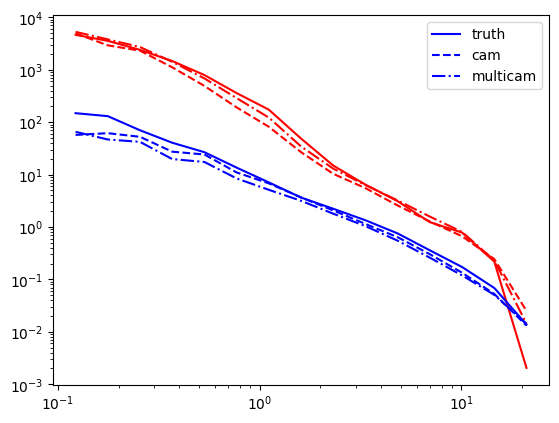

In [32]:
plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b", label="truth")


plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--", label="cam")

plt.loglog(rbin_centers, xi_red_multicam, c="r", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="b", ls="-.", label="multicam")

plt.legend()

In [33]:
# colorless clustering
xyz = return_xyz_formatted_array(
    hydro_mstar_cut["x"].data, hydro_mstar_cut["y"].data, hydro_mstar_cut["z"].data
)
xi_true = tpcf(xyz, rbins, randoms=randoms, period=Lbox, num_threads="max")

xyz = return_xyz_formatted_array(
    hydro_sham["x"].data, hydro_sham["y"].data, hydro_sham["z"].data
)
xi_sham = tpcf(xyz, rbins, randoms=randoms, period=Lbox, num_threads="max")


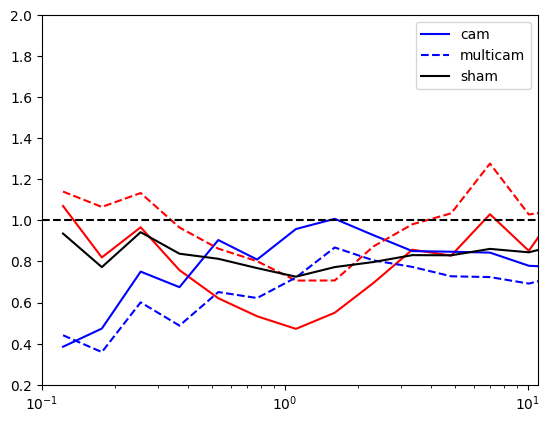

In [34]:
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-", label="cam")

plt.semilogx(rbin_centers, xi_red_multicam / xi_red_true, c="r", ls="--")
plt.semilogx(
    rbin_centers, xi_blue_multicam / xi_blue_true, c="b", ls="--", label="multicam"
)
plt.semilogx(
    rbin_centers, xi_sham / xi_true, c="k", ls="-", label="sham"
)  # colorless clustering

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.legend()

In [35]:
# they both up and down with respect to sham line, so is one really better than the other?
# maybe it's all statistical noise so shouldn't read into this trend too much?
# NOTE: color prediction even though it's better CAN'T correc the bias in the black prediction!
# also not ehow red/blue need to "cancel" each other by definition (weighted by true number of objects in each)

# Use true stellar mass bin instead 

In [37]:
# prediction on true stellar mass bin from CAM ("mstar_cut")
_color_cam_pred = qt(hydro_mstar_cut["z12"].data, hydro_mstar_cut["color"])


In [38]:
# multicam on hydro_mstar_cut
# NOTE: can only train multicam on mpeak mass bin
_x = np.log10(hydro_raw["mpeak"])
mask = (_x > 11) & (_x < 12)
hydro_mpeak = hydro_raw[mask]

x_train = get_an_from_mpeak_mah(hydro_mpeak["mpeak_mah"], scales=scales, ns=ns)
y_train = hydro_mpeak["color"].reshape(-1, 1)

# but we want to apply on SHAM bin
x_test = get_an_from_mpeak_mah(hydro_mstar_cut["mpeak_mah"], scales=scales, ns=ns)

# and reproduce the color distribution in the true stellar mass bin!
y_true = hydro_mstar_cut["color"].reshape(-1, 1)


In [42]:
model = MultiCAM(9, 1)
model.fit(x_train, y_train)  # train on the same as last section
_color_multicam_pred = model.predict(x_test, y_target=y_true)[..., 0]
_color_multicam_pred.shape

(4050,)

In [43]:
# spearman, in true star mass bin, lower than in SHAM bin
(
    spearmanr(_color_cam_pred, hydro_mstar_cut["color"].data).statistic,
    spearmanr(_color_multicam_pred, hydro_mstar_cut["color"].data).statistic,
)
# also larger, both reduced


(np.float64(0.5834459380284716), np.float64(0.6556266025024865))

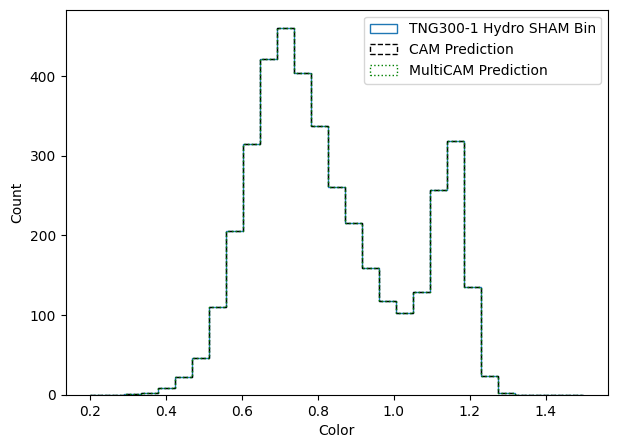

In [44]:
# histogram of color distribution
# obvioulsy still the same
plt.figure(figsize=(7, 5))
bins = np.linspace(0.2, 1.5, 30)
plt.hist(
    hydro_mstar_cut["color"].data,
    bins=bins,
    histtype="step",
    label="TNG300-1 Hydro SHAM Bin",
)
plt.hist(
    _color_cam_pred,
    bins=bins,
    histtype="step",
    ls="--",
    label="CAM Prediction",
    color="k",
)
plt.hist(
    _color_multicam_pred,
    bins=bins,
    histtype="step",
    ls=":",
    label="MultiCAM Prediction",
    color="g",
)
plt.xlabel("Color")
plt.ylabel("Count")
plt.legend()


## Clustering on true stellar mass bin, multicam needs to be better

In [45]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(lbox=Lbox, n_randoms=50_000, rng=41)

randoms.shape

(50000, 3)

In [46]:
true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]


red_pred = hydro_mstar_cut[_color_cam_pred > COLOR_CUT]
blue_pred = hydro_mstar_cut[_color_cam_pred <= COLOR_CUT]

multicam_red_pred = hydro_mstar_cut[_color_multicam_pred > COLOR_CUT]
multicam_blue_pred = hydro_mstar_cut[_color_multicam_pred <= COLOR_CUT]

In [47]:
(
    len(red_pred),
    len(red_true),
    len(multicam_red_pred),
    len(blue_true),
    len(blue_pred),
    len(multicam_blue_pred),
)

(981, 981, 981, 3069, 3069, 3069)

In [48]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [49]:
xyz_red = return_xyz_formatted_array(
    red_pred["x"].data, red_pred["y"].data, red_pred["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_pred["x"].data, blue_pred["y"].data, blue_pred["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [50]:
xyz_red = return_xyz_formatted_array(
    multicam_red_pred["x"].data,
    multicam_red_pred["y"].data,
    multicam_red_pred["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue_pred["x"].data,
    multicam_blue_pred["y"].data,
    multicam_blue_pred["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


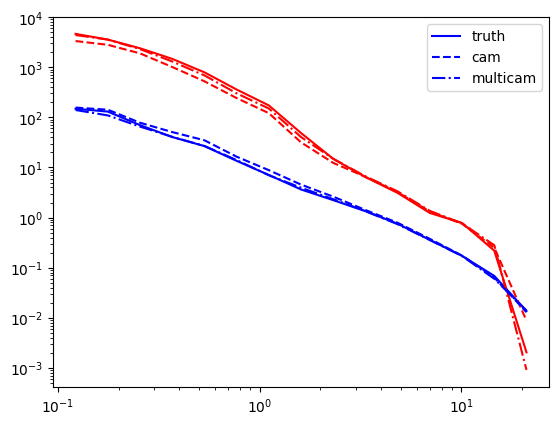

In [51]:
plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b", label="truth")


plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--", label="cam")

plt.loglog(rbin_centers, xi_red_multicam, c="r", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="b", ls="-.", label="multicam")

plt.legend()

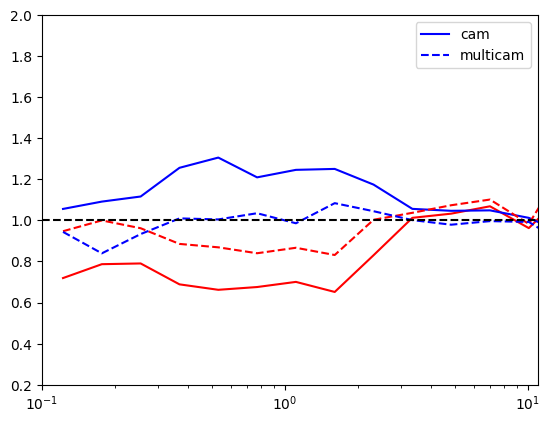

In [52]:
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-", label="cam")

plt.semilogx(rbin_centers, xi_red_multicam / xi_red_true, c="r", ls="--")
plt.semilogx(
    rbin_centers, xi_blue_multicam / xi_blue_true, c="b", ls="--", label="multicam"
)

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.legend()

# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output

In [53]:
# great that clarifies some things I think specifically that most of the 'bias' we see in MultiCAM
# comes from the SHAM step?

# Now with M* refinement

In [14]:
# procedure is broadly to train MultiCAM the same way but also in the deviation from SHMR
# on the same mpeak mass bin, then use this deviation to get a refined mock stellar mass bin
# then do another prediction in this new bin for color; this last step is required so that we can
# force distribution of the final mock stellar mass bin to be exactly the same as the true color distribution in the true stellar mass bin

In [ ]:
# decide which a_n's
ns = np.linspace(0, 1, 11)[1:-1]
ns

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [54]:
# NOTE: can only train multicam on mpeak mass bin
_x = np.log10(hydro_raw["mpeak"])
mask = (_x > 11) & (_x < 12)
hydro_mpeak = hydro_raw[mask]


In [156]:
# get deviation from SHMR

# this only has resolution cut (mpeak > 11)
delta_shmr = np.log10(hydro_high["stellar_mass"]) - logmstar_sham_high

# for training
_x = np.log10(hydro_high["mpeak"])
_mask = _x < 12
delta_shmr_train = delta_shmr[_mask]

# # for 'truth' stellar mass bin
# # no cut on MPeak < 12
# _x = np.log10(hydro_high["stellar_mass"])
# _mask = (_x > 9.5) & (_x < 10.2)
# delta_shmr_true = delta_shmr[_mask]


len(hydro_mpeak), delta_shmr_train.shape
# delta_shmr_true.shape

(11310, (11310,))

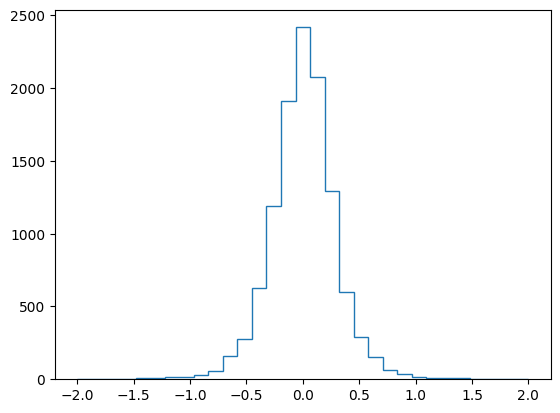

In [157]:
# distribution of deviation from SHMR
plt.hist(delta_shmr_train, bins=31, range=(-2, 2), histtype="step");

In [158]:
# multicam is trained once with the following features and targets
x_train = get_an_from_mpeak_mah(hydro_mpeak["mpeak_mah"], scales=scales, ns=ns)

y_train = np.concatenate(
    [hydro_mpeak["color"].reshape(-1, 1), delta_shmr_train.reshape(-1, 1)], axis=-1
)
x_train.shape, y_train.shape

((11310, 9), (11310, 2))

In [159]:
# train only once!
model = MultiCAM(9, 2)
model.fit(x_train, y_train)

In [160]:
# get m* mock prediction
# x_test1 = get_an_from_mpeak_mah(hydro_sham["mpeak_mah"], scales=scales, ns=ns)
# y_true1 = np.concatenate(
#     [hydro_mstar_cut["color"].reshape(-1, 1), delta_shmr_true.reshape(-1, 1)], axis=-1
# )

# NOTE: do it on train! broader bin that needs to be refined.
y_pred1 = model.predict(x_train, y_target=y_train)
y_pred1.shape

(11310, 2)

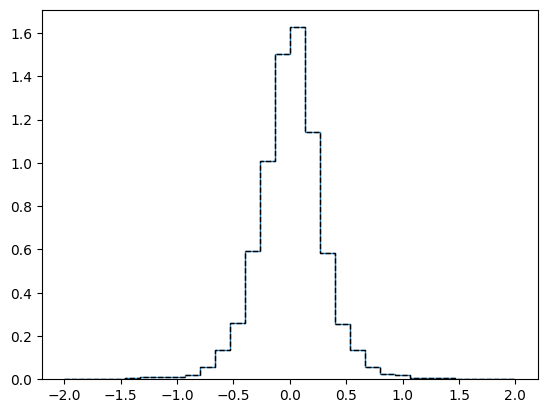

In [161]:
# just sanity check histograms
bins = np.linspace(-2, 2, 31)
plt.hist(y_pred1[:, 1], bins=bins, histtype="step", density=True)
plt.hist(y_train[:, 1], bins=bins, histtype="step", ls="--", color="k", density=True);

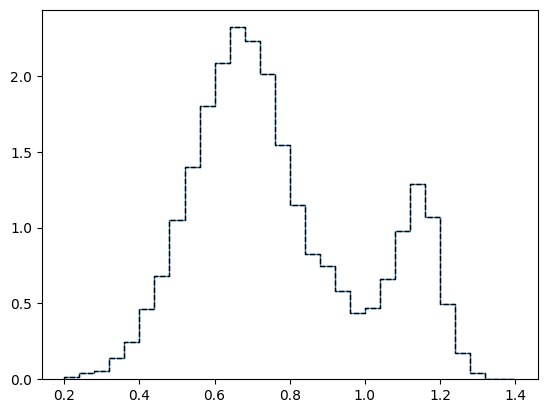

In [162]:
bins = np.linspace(0.2, 1.4, 31)
plt.hist(y_train[:, 0], bins=bins, histtype="step", density=True)
plt.hist(y_pred1[:, 0], bins=bins, histtype="step", ls="--", color="k", density=True);

In [163]:
# now "refine" using SHAM bin as a basis
delta_pred = y_pred1[:, 1]
_mask = np.log10(hydro_high["mpeak"]) < 12
logm_star_pred = delta_pred + logmstar_sham_high[_mask]


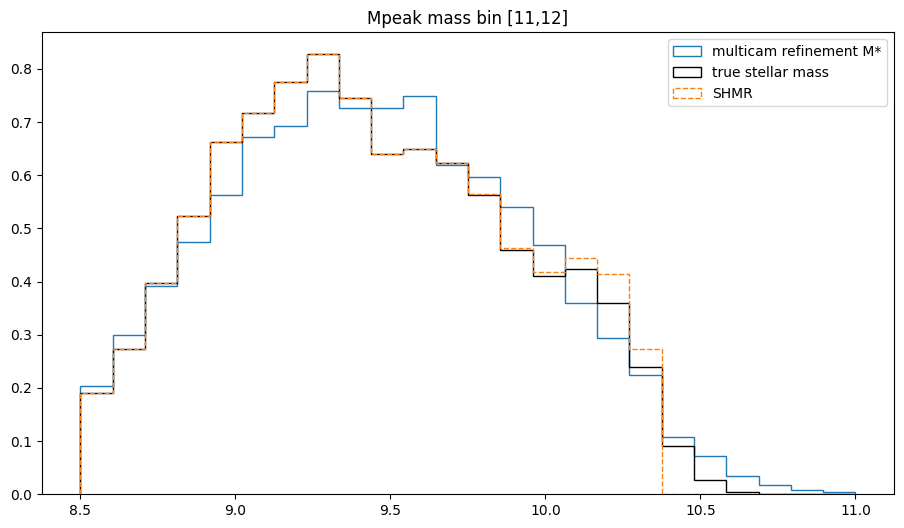

In [164]:
# now compare mstar with truth (same bin and true stellar bin)...

bins = np.linspace(8.5, 11.0, 25)

plt.figure(figsize=(11, 6))
plt.hist(
    logm_star_pred,
    bins=bins,
    histtype="step",
    label="multicam refinement M*",
    density=True,
)
plt.hist(
    np.log10(hydro_high["stellar_mass"][_mask]),
    bins=bins,
    histtype="step",
    label="true stellar mass",  # on mpeak mass bin
    density=True,
    color="k",
    ls="-",
)
plt.hist(
    logmstar_sham_high[_mask],
    bins=bins,
    histtype="step",
    label="SHMR",
    density=True,
    ls="--",
)
plt.title("Mpeak mass bin [11,12]")
plt.legend(loc="best");
# TODO: could we also predict M* directly better in the first rather than refine?

In [165]:
# y_true = np.concatenate([hydro_mstar_cut["color"]])
_mask = (logm_star_pred > 9.5) & (logm_star_pred < 10.2)
hydro_multicam = hydro_mpeak[_mask]
len(hydro_multicam)

4161

In [166]:
x_train2 = get_an_from_mpeak_mah(hydro_multicam["mpeak_mah"], scales=scales, ns=ns)

_dummy = np.ones_like(hydro_mstar_cut["color"]).reshape(-1, 1)
y_true = np.concatenate([hydro_mstar_cut["color"].reshape(-1, 1), _dummy], axis=-1)

multicam_color = model.predict(x_train2, y_target=y_true)[:, 0]
multicam_color.shape

(4161,)

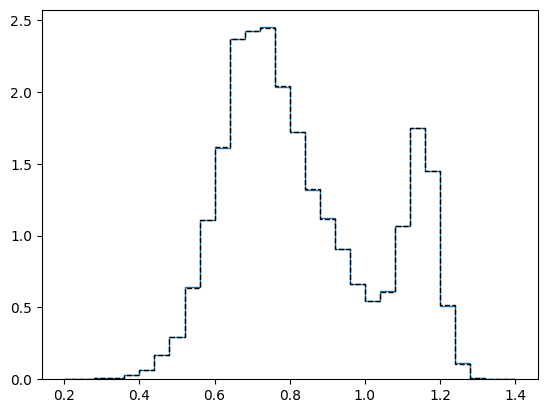

In [167]:
# sanity
bins = np.linspace(0.2, 1.4, 31)
plt.hist(hydro_mstar_cut["color"], bins=bins, histtype="step", density=True)
plt.hist(multicam_color, bins=bins, histtype="step", ls="--", color="k", density=True);

## Clustering

In [136]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(lbox=Lbox, n_randoms=50_000, rng=41)

randoms.shape

(50000, 3)

In [137]:
true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]


red_pred = hydro_sham[color_cam_pred > COLOR_CUT]
blue_pred = hydro_sham[color_cam_pred <= COLOR_CUT]

multicam_red_pred = hydro_multicam[multicam_color > COLOR_CUT]
multicam_blue_pred = hydro_multicam[multicam_color <= COLOR_CUT]

In [138]:
(
    len(red_pred),
    len(red_true),
    len(multicam_red_pred),
    len(blue_true),
    len(blue_pred),
    len(multicam_blue_pred),
)

(981, 981, 1008, 3069, 3069, 3153)

In [139]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [140]:
xyz_red = return_xyz_formatted_array(
    red_pred["x"].data, red_pred["y"].data, red_pred["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_pred["x"].data, blue_pred["y"].data, blue_pred["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [141]:
xyz_red = return_xyz_formatted_array(
    multicam_red_pred["x"].data,
    multicam_red_pred["y"].data,
    multicam_red_pred["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue_pred["x"].data,
    multicam_blue_pred["y"].data,
    multicam_blue_pred["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


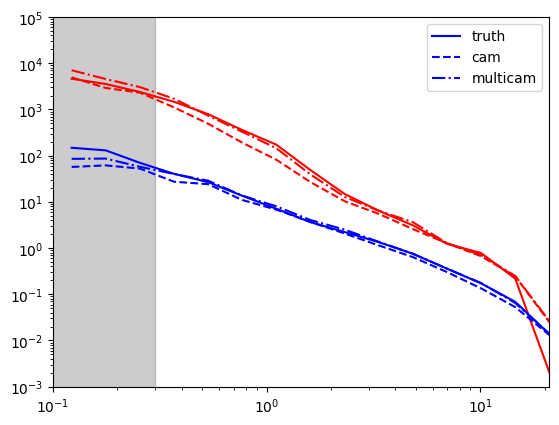

In [149]:
plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b", label="truth")


plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--", label="cam")

plt.loglog(rbin_centers, xi_red_multicam, c="r", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="b", ls="-.", label="multicam")

plt.fill_betweenx([1e-5, 1e7], 0.01, 0.3, color="k", alpha=0.2)
plt.xlim(0.1, 21)
plt.ylim(1e-3, 1e5)
plt.legend()

In [143]:
# colorless clustering
xyz = return_xyz_formatted_array(
    hydro_mstar_cut["x"].data, hydro_mstar_cut["y"].data, hydro_mstar_cut["z"].data
)
xi_true = tpcf(xyz, rbins, randoms=randoms, period=Lbox, num_threads="max")

xyz = return_xyz_formatted_array(
    hydro_sham["x"].data, hydro_sham["y"].data, hydro_sham["z"].data
)
xi_sham = tpcf(xyz, rbins, randoms=randoms, period=Lbox, num_threads="max")


xyz = return_xyz_formatted_array(
    hydro_multicam["x"].data, hydro_multicam["y"].data, hydro_multicam["z"].data
)
xi_multicam = tpcf(xyz, rbins, randoms=randoms, period=Lbox, num_threads="max")


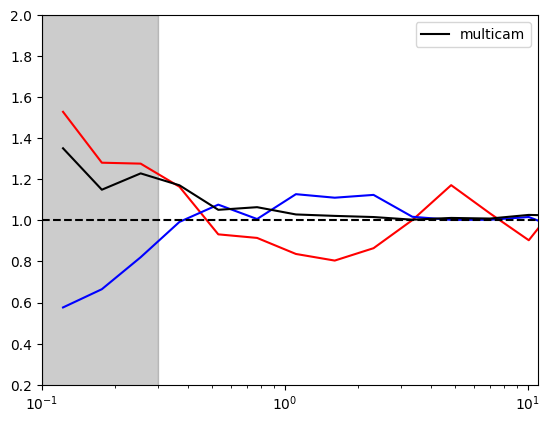

In [153]:
# plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")
# plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-", label="cam")

plt.semilogx(rbin_centers, xi_red_multicam / xi_red_true, c="r", ls="-")
plt.semilogx(
    rbin_centers,
    xi_blue_multicam / xi_blue_true,
    c="b",
    ls="-",
)
# )
# plt.semilogx(
#     rbin_centers, xi_sham / xi_true, c="k", ls="-", label="sham"
# )  # colorless clustering
plt.semilogx(
    rbin_centers, xi_multicam / xi_true, c="k", ls="-", label="multicam"
)  # colorless clustering

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.fill_betweenx([-2, 2], 0.1, 0.3, color="k", alpha=0.2)


plt.legend()